100%|██████████| 10/10 [00:05<00:00,  1.96it/s]


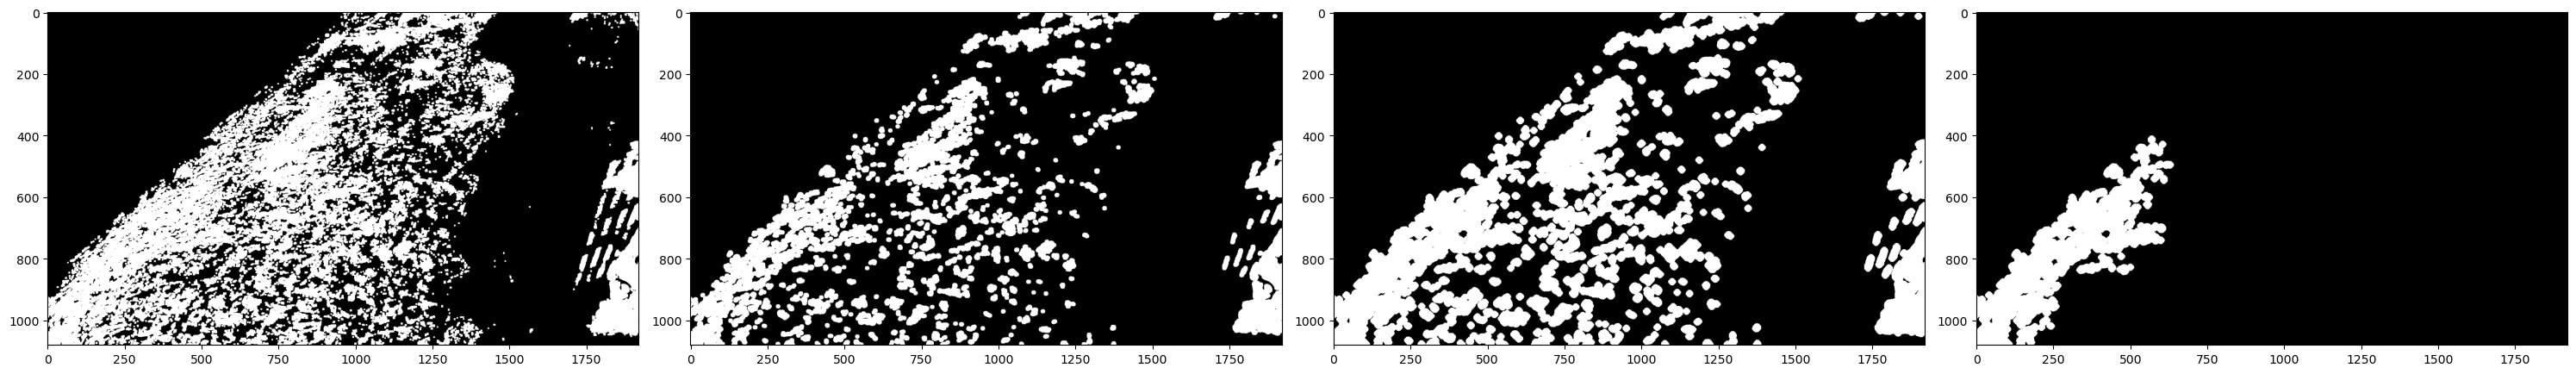

100%|██████████| 10/10 [00:20<00:00,  2.02s/it]


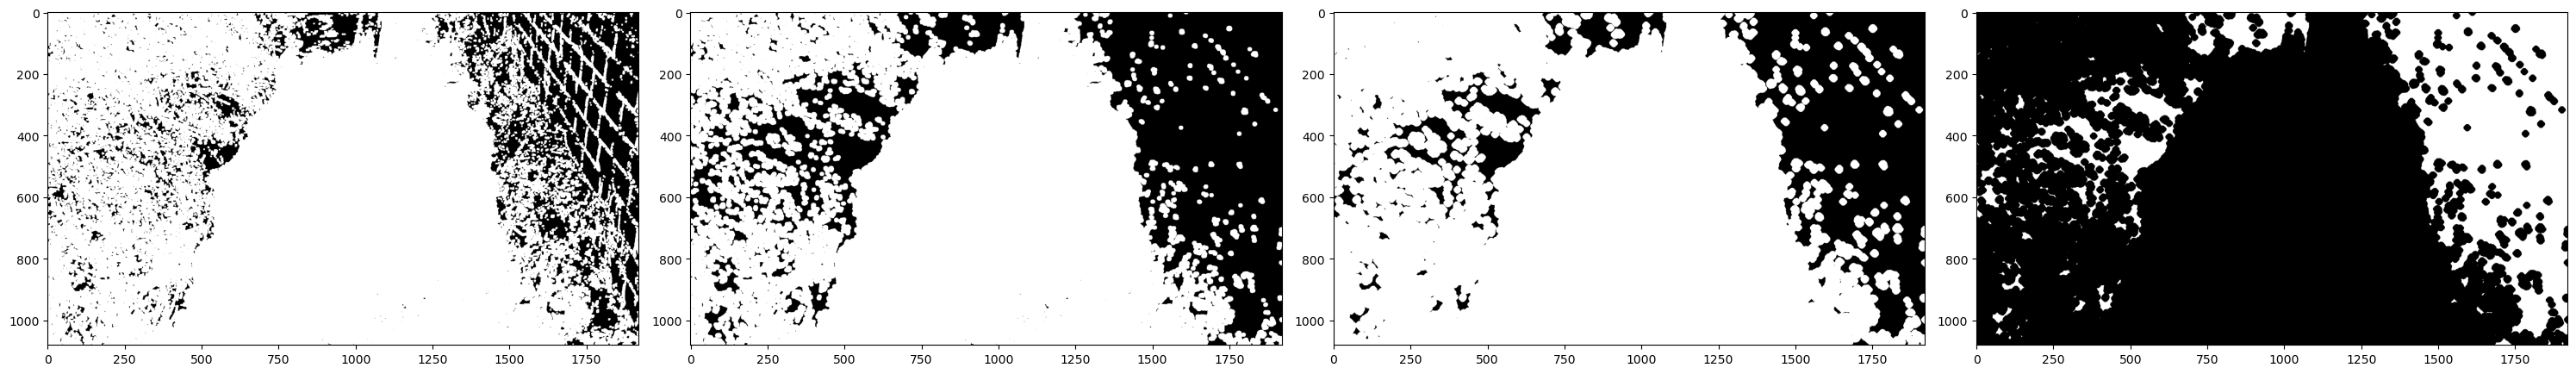

100%|██████████| 10/10 [00:09<00:00,  1.00it/s]


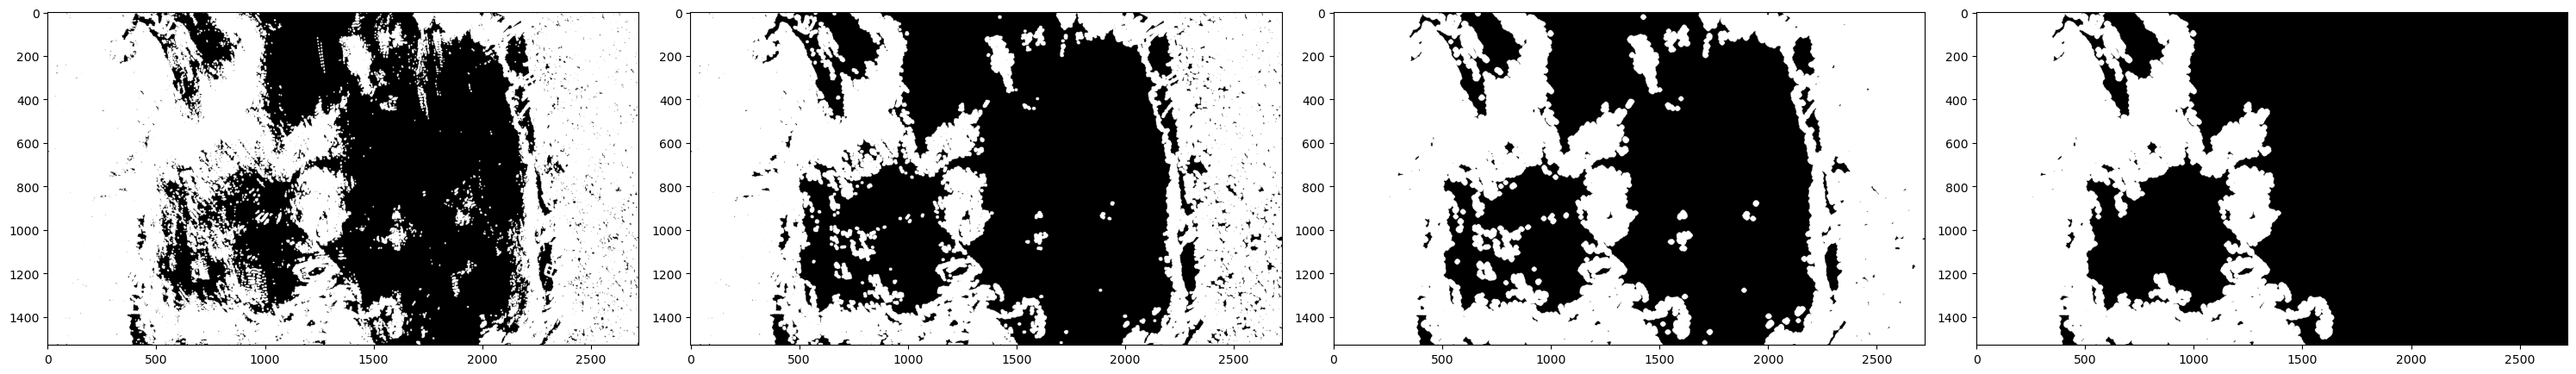

100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


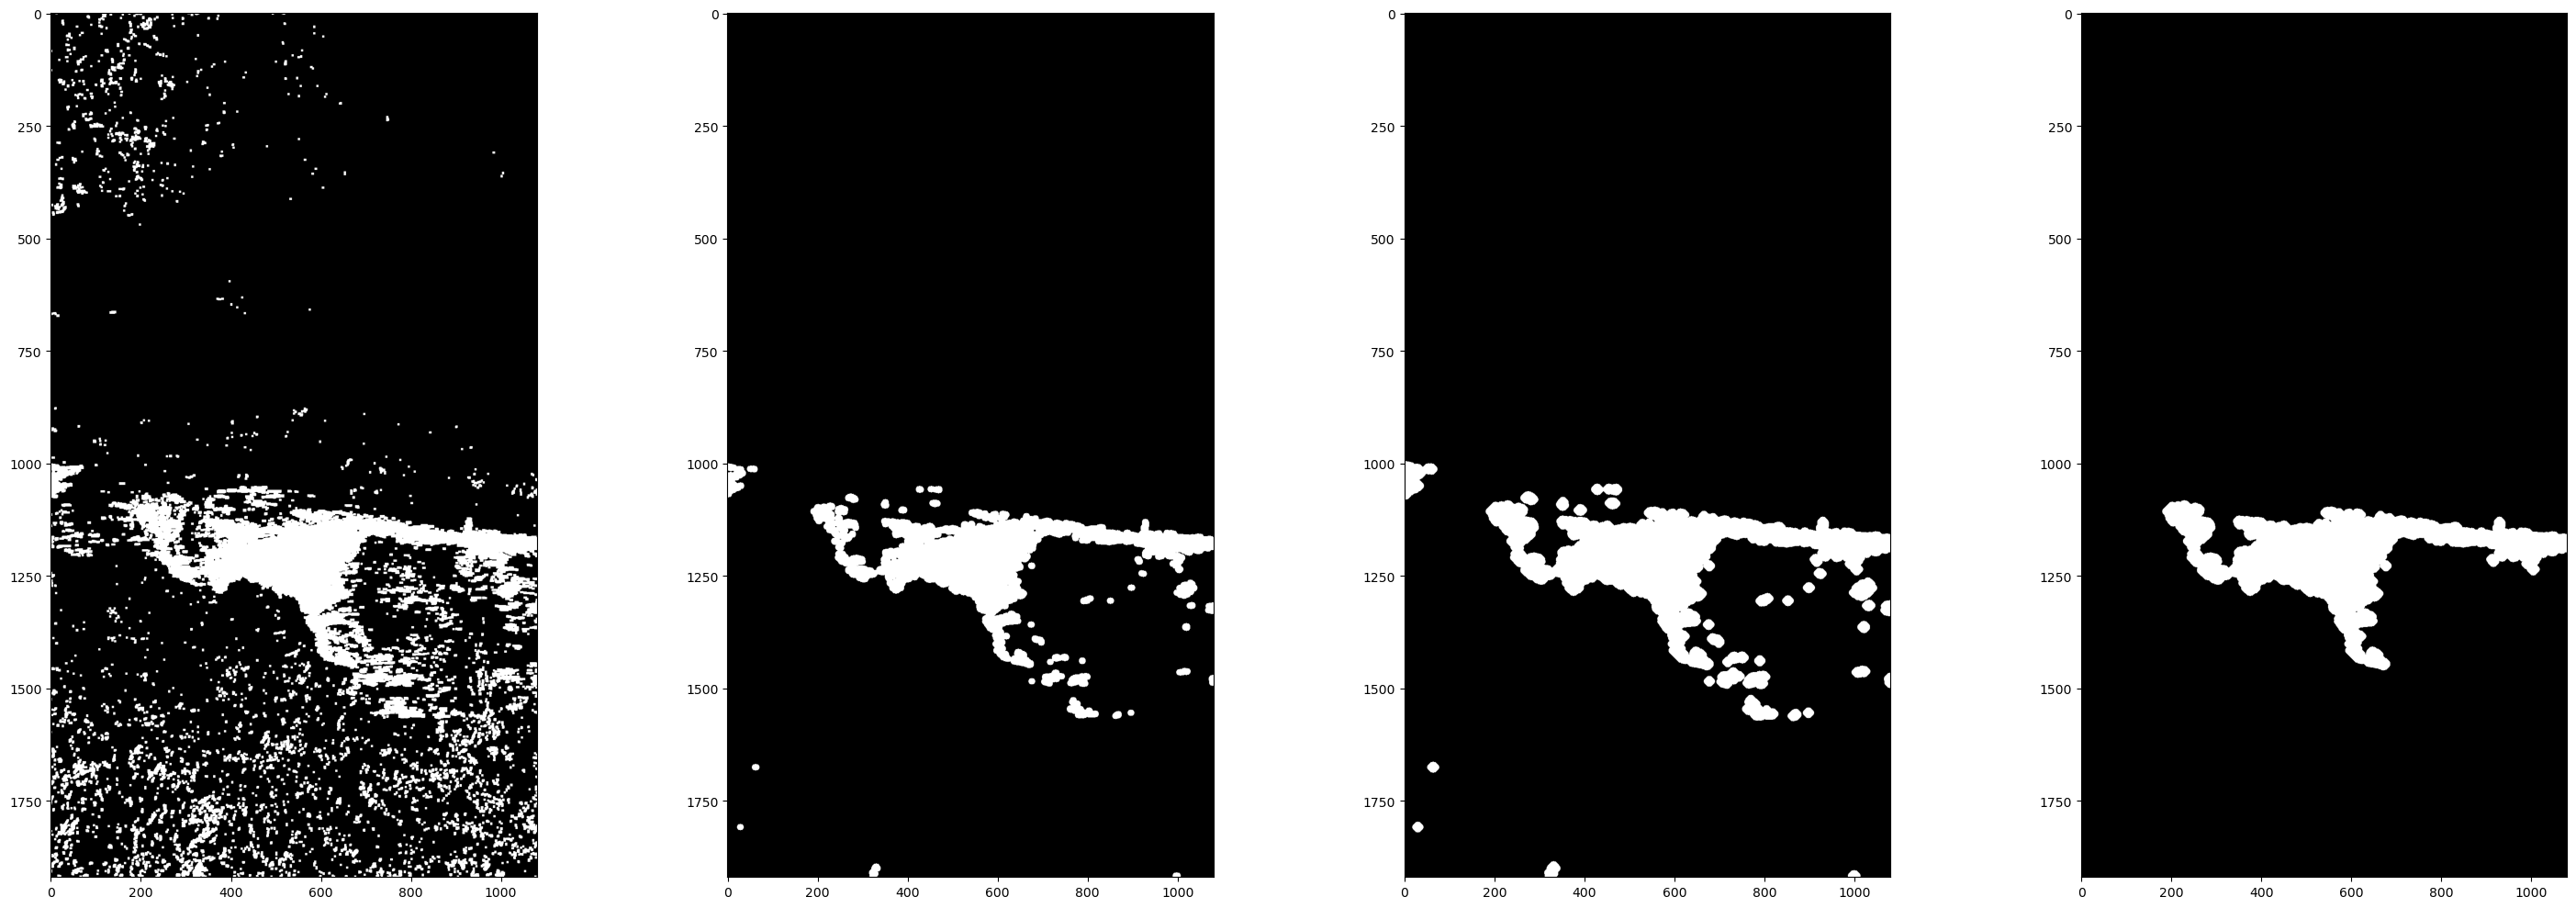

In [35]:
import pyorc
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from tqdm import tqdm

filepaths = []
filepaths.append("../examples/VGC1/VGC1.mp4")
filepaths.append("../examples/data/Noirath/Vidéo première utilisation_stabilized.mp4")
filepaths.append("../examples/data/Limelette/Limelette_drone.mp4")
filepaths.append("../examples/data/Rosière/video_stabilized.mp4")
for j in range(0, 4):
    filepath = filepaths[j]


    video = cv2.VideoCapture(filepath)
    fps = video.get(cv2.CAP_PROP_FPS)
    start_frame = int(5*fps)
    end_frame = start_frame + 50
    video = pyorc.Video(filepath, start_frame=start_frame, end_frame=end_frame)

    mask = np.zeros_like(video.get_frame(0, method='grayscale'))
    previous_frame = None

    for i in tqdm(range(0, 20, 2)):
        prepared_frame = video.get_frame(i, method='grayscale')
        prepared_frame = cv2.GaussianBlur(src=prepared_frame, ksize=(5, 5), sigmaX=0)

        if (previous_frame is None):
            previous_frame = prepared_frame
            continue

        diff_frame = cv2.absdiff(src1=previous_frame, src2=prepared_frame)
        previous_frame = prepared_frame

        kernel = np.ones((5, 5))
        diff_frame = cv2.dilate(diff_frame, kernel, 1)

        thresh_frame = cv2.threshold(src=diff_frame, thresh=20, maxval=255, type=cv2.THRESH_BINARY)[1]

        mask = np.logical_or(mask, thresh_frame)

    mask_transformed = mask.astype(np.uint8)

    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    opening = cv2.morphologyEx(mask_transformed, cv2.MORPH_OPEN, kernel2)

    kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    dilation = cv2.morphologyEx(opening, cv2.MORPH_DILATE, kernel3, iterations=5)

    objects, nb_objects = ndimage.label(dilation)

    count = np.bincount(objects.ravel())
    good_label = (-count).argsort()[1]  # take indices of 4 bigger numbered labeled

    river_mask = np.zeros_like(mask_transformed)
    river_mask[objects == good_label] = 1

    fig, ax = plt.subplots(1, 4, figsize=(30,10))
    ax[0].imshow(mask, cmap='gray')
    ax[1].imshow(opening, cmap='gray')
    ax[2].imshow(dilation, cmap='gray')
    ax[3].imshow(river_mask, cmap='gray')
    plt.tight_layout()
    plt.show()